# **Import Libraries**

In [4]:
!pip install opendatasets
import opendatasets as od

In [5]:
!pip install lime

In [23]:
import os
import shutil
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils import class_weight
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from lime import lime_image
from skimage.segmentation import mark_boundaries
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adamax
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
from sklearn.metrics import accuracy_score

from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, average_precision_score
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import precision_recall_fscore_support


# **Load & Prepare Data**

In [113]:
ham_url = "https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000"
isic_url = "https://www.kaggle.com/datasets/nodoubttome/skin-cancer9-classesisic"

print("Downloading HAM10000...")
od.download(ham_url)
print("Downloading ISIC 9 Classes...")
od.download(isic_url)


Skipping, found downloaded files in "./skin-cancer-mnist-ham10000" (use force=True to force download)
Skipping, found downloaded files in "./skin-cancer9-classesisic" (use force=True to force download)


In [119]:
master_dir = 'unified_dataset'
os.makedirs(master_dir, exist_ok=True)

ham_mapping = {'nv': 'melanocytic_nevi', 'mel': 'melanoma', 'bcc': 'basal_cell_carcinoma',
               'akiec': 'actinic_keratosis', 'bkl': 'benign_keratosis', 'df': 'dermatofibroma',
               'vasc': 'vascular_lesion'}

isic_mapping = {'actinic keratosis': 'actinic_keratosis', 'basal cell carcinoma': 'basal_cell_carcinoma',
                'dermatofibroma': 'dermatofibroma', 'melanoma': 'melanoma', 'nevus': 'melanocytic_nevi',
                'pigmented benign keratosis': 'benign_keratosis', 'seborrheic keratosis': 'benign_keratosis',
                'squamous cell carcinoma': 'actinic_keratosis', 'vascular lesion': 'vascular_lesion'}

ham_base = 'skin-cancer-mnist-ham10000'
metadata = pd.read_csv(f'{ham_base}/HAM10000_metadata.csv')
ham_folders = [f'{ham_base}/ham10000_images_part_1', f'{ham_base}/ham10000_images_part_2']

print("Processing HAM10000...")
for _, row in metadata.iterrows():
    label = ham_mapping[row['dx']]
    dest = os.path.join(master_dir, label)
    os.makedirs(dest, exist_ok=True)
    img_name = row['image_id'] + '.jpg'
    for folder in ham_folders:
        src = os.path.join(folder, img_name)
        if os.path.exists(src):
            shutil.copy(src, os.path.join(dest, img_name))
            break

print("Processing ISIC 9 Classes...")
isic_root = 'skin-cancer9-classesisic/Skin cancer ISIC The International Skin Imaging Collaboration'
for split in ['Train', 'Test']:
    split_path = os.path.join(isic_root, split)
    if not os.path.exists(split_path): continue
    for folder_name in os.listdir(split_path):
        if folder_name in isic_mapping:
            target_label = isic_mapping[folder_name]
            dest_folder = os.path.join(master_dir, target_label)
            os.makedirs(dest_folder, exist_ok=True)
            src_folder = os.path.join(split_path, folder_name)
            for img in os.listdir(src_folder):
                safe_img_name = f"isic9_{split.lower()}_{img}"
                shutil.copy(os.path.join(src_folder, img), os.path.join(dest_folder, safe_img_name))

print(f"Done! Dataset ready in '{master_dir}' folder.")

Processing HAM10000...
Processing ISIC 9 Classes...
Done! Dataset ready in 'unified_dataset' folder.


In [111]:
base_dir = "unified_dataset"

classes = sorted(os.listdir(base_dir))
num_classes = len(classes)

print("Classes:", classes)
print("Number of classes:", num_classes)

Classes: ['actinic_keratosis', 'basal_cell_carcinoma', 'benign_keratosis', 'dermatofibroma', 'melanocytic_nevi', 'melanoma', 'vascular_lesion']
Number of classes: 7


# **Data Preprocessing**

In [112]:
import os
import shutil
import random

base_dir = "unified_dataset"
train_dir = "train_dataset"
test_dir = "test_dataset"

os.makedirs(train_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

split_ratio = 0.15

for cls in os.listdir(base_dir):
    cls_path = os.path.join(base_dir, cls)
    if not os.path.isdir(cls_path):
        continue

    images = os.listdir(cls_path)
    random.shuffle(images)

    split_idx = int(len(images) * (1 - split_ratio))

    train_imgs = images[:split_idx]
    test_imgs = images[split_idx:]

    os.makedirs(os.path.join(train_dir, cls), exist_ok=True)
    os.makedirs(os.path.join(test_dir, cls), exist_ok=True)

    for img in train_imgs:
        shutil.copy(os.path.join(cls_path, img),
                    os.path.join(train_dir, cls, img))

    for img in test_imgs:
        shutil.copy(os.path.join(cls_path, img),
                    os.path.join(test_dir, cls, img))

In [115]:
img_size = (64, 64)
batch_size = 32
base_dir = "unified_dataset"

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = datagen.flow_from_directory(
    "train_dataset",
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_generator = datagen.flow_from_directory(
    "train_dataset",
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    "test_dataset",
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)


print("Classes:", train_generator.class_indices)
print("Train samples:", train_generator.samples)
print("Validation samples:", val_generator.samples)
print("Test samples:", test_generator.samples)

Found 38772 images belonging to 7 classes.
Found 9690 images belonging to 7 classes.
Found 13784 images belonging to 7 classes.
Classes: {'actinic_keratosis': 0, 'basal_cell_carcinoma': 1, 'benign_keratosis': 2, 'dermatofibroma': 3, 'melanocytic_nevi': 4, 'melanoma': 5, 'vascular_lesion': 6}
Train samples: 38772
Validation samples: 9690
Test samples: 13784


In [116]:
import os
import random
import shutil
from collections import Counter
base_dir = "train_dataset"
class_counts = {}
for cls in os.listdir(base_dir):
    cls_path = os.path.join(base_dir, cls)
    if os.path.isdir(cls_path):
        class_counts[cls] = len(os.listdir(cls_path))

max_count = max(class_counts.values())

for cls, count in class_counts.items():
    cls_path = os.path.join(base_dir, cls)
    images = os.listdir(cls_path)

    if count < max_count:
        needed = max_count - count

        for i in range(needed):
            img_name = random.choice(images)
            src = os.path.join(cls_path, img_name)

            new_name = f"aug_{i}_{img_name}"
            dst = os.path.join(cls_path, new_name)

            shutil.copy(src, dst)

print("Oversampling completed!")

Oversampling completed!


# **EDA**

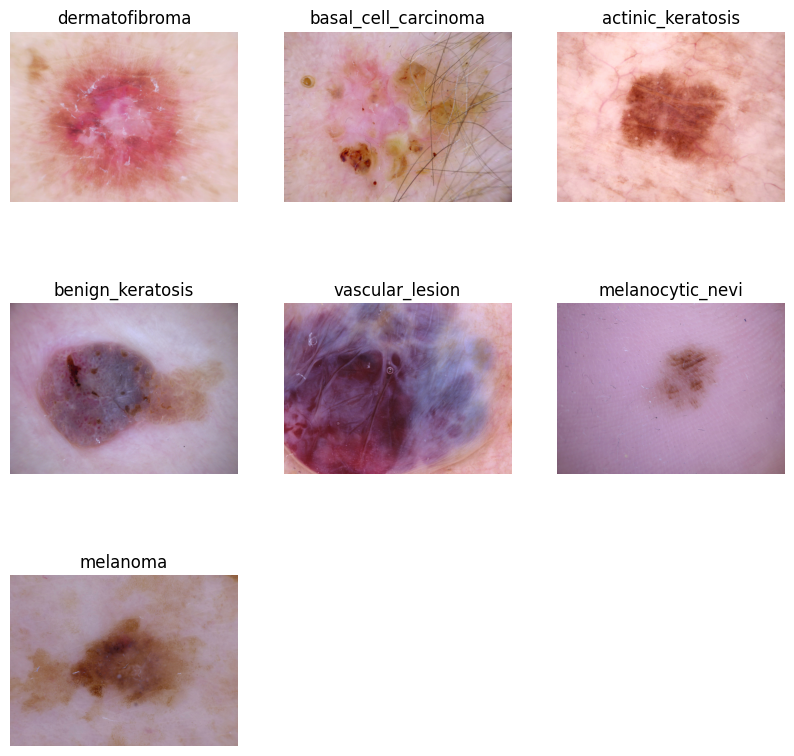

In [59]:
base = "unified_dataset"

plt.figure(figsize=(10,10))

i = 1
for cls in os.listdir(base):
    img_path = os.path.join(base, cls, os.listdir(os.path.join(base, cls))[0])
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(3,3,i)
    plt.title(cls)
    plt.imshow(img)
    plt.axis('off')
    i += 1

plt.show()

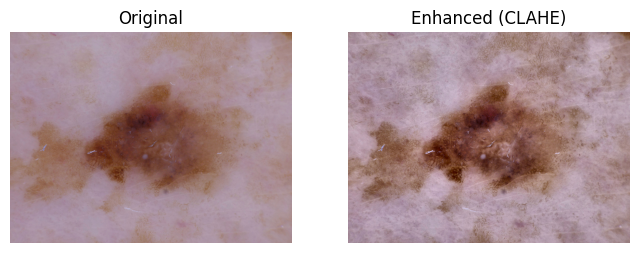

In [60]:
input_dir = "unified_dataset"
cls_name = "melanoma"
img_filename = os.listdir(os.path.join(input_dir, cls_name))[0]
img_path = os.path.join(input_dir, cls_name, img_filename)

original_img = cv2.imread(img_path)
original_img_rgb = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)

lab = cv2.cvtColor(original_img, cv2.COLOR_BGR2LAB)
l, a, b = cv2.split(lab)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
l_enhanced = clahe.apply(l)
final_lab = cv2.merge((l_enhanced, a, b))
enhanced_img_rgb = cv2.cvtColor(final_lab, cv2.COLOR_LAB2BGR)
enhanced_img_rgb = cv2.cvtColor(enhanced_img_rgb, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.title("Original")
plt.imshow(original_img_rgb)
plt.axis('off')

plt.subplot(1,2,2)
plt.title("Enhanced (CLAHE)")
plt.imshow(enhanced_img_rgb)
plt.axis('off')

plt.show()

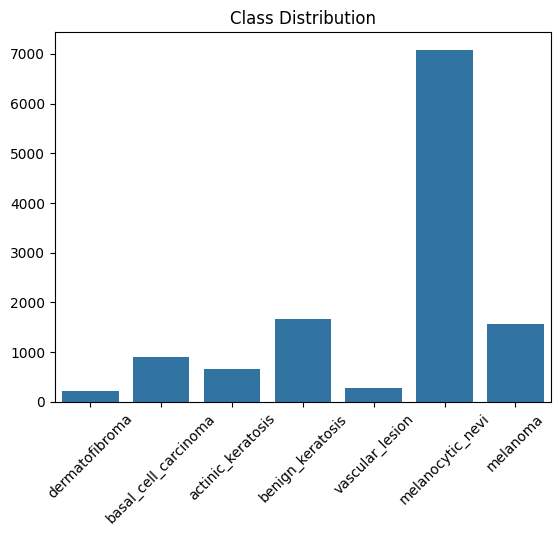

In [120]:
import seaborn as sns

counts = []
labels = []

for cls in os.listdir("unified_dataset"):
    count = len(os.listdir(os.path.join("unified_dataset", cls)))
    counts.append(count)
    labels.append(cls)

sns.barplot(x=labels, y=counts)
plt.xticks(rotation=45)
plt.title("Class Distribution")
plt.show()

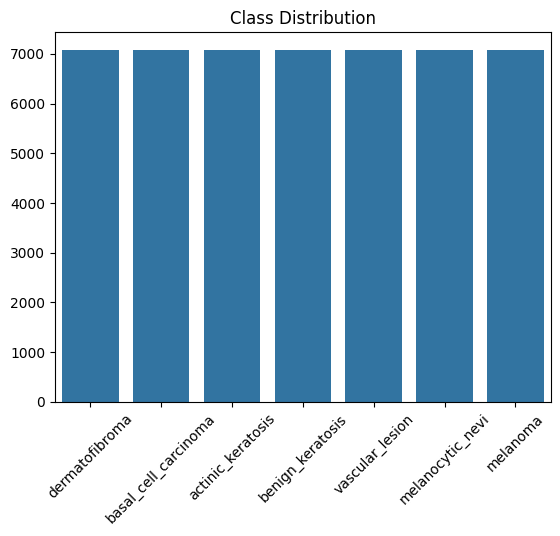

In [117]:
import seaborn as sns

counts = []
labels = []

for cls in os.listdir(base):
    count = len(os.listdir(os.path.join(base, cls)))
    counts.append(count)
    labels.append(cls)

sns.barplot(x=labels, y=counts)
plt.xticks(rotation=45)
plt.title("Class Distribution")
plt.show()

In [62]:
import pandas as pd

df = pd.read_csv("skin-cancer-mnist-ham10000/HAM10000_metadata.csv")

print(df.head())

     lesion_id      image_id   dx dx_type   age   sex localization
0  HAM_0000118  ISIC_0027419  bkl   histo  80.0  male        scalp
1  HAM_0000118  ISIC_0025030  bkl   histo  80.0  male        scalp
2  HAM_0002730  ISIC_0026769  bkl   histo  80.0  male        scalp
3  HAM_0002730  ISIC_0025661  bkl   histo  80.0  male        scalp
4  HAM_0001466  ISIC_0031633  bkl   histo  75.0  male          ear


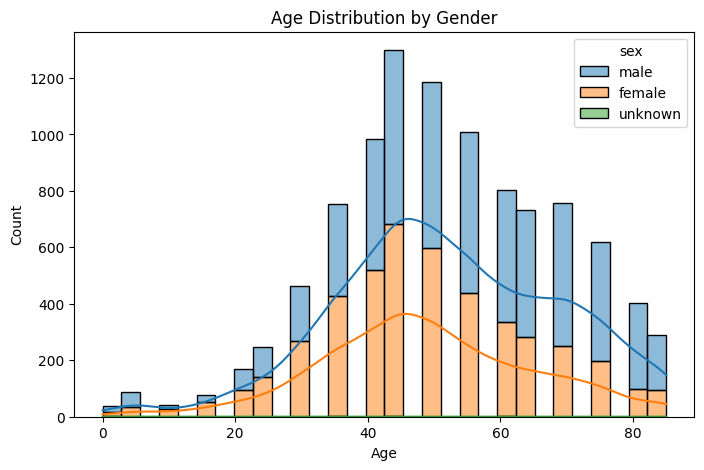

In [63]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="age",
    hue="sex",
    bins=30,
    kde=True,
    multiple="stack"
)

plt.title("Age Distribution by Gender")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

/tmp/ipykernel_701/1966159067.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='sex', palette='pastel', ax=ax)


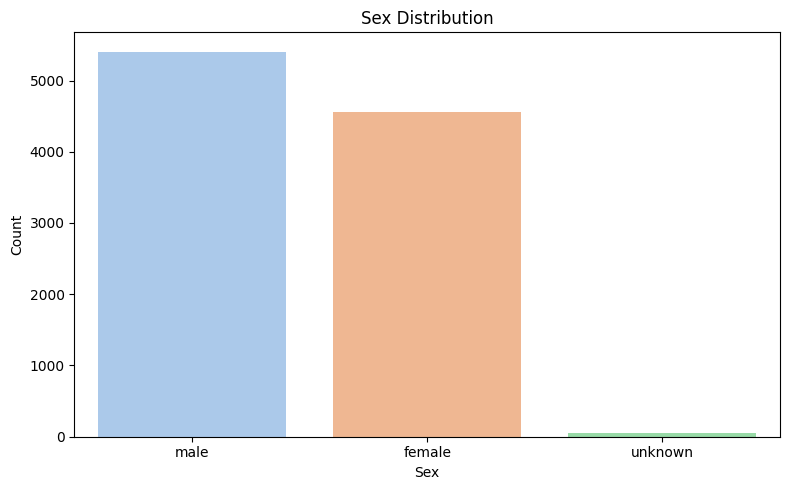

In [64]:
gender_counts = df['sex'].value_counts()

fig, ax = plt.subplots(1, 1, figsize=(8, 5))
sns.countplot(data=df, x='sex', palette='pastel', ax=ax)
ax.set_title('Sex Distribution')
ax.set_xlabel('Sex')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

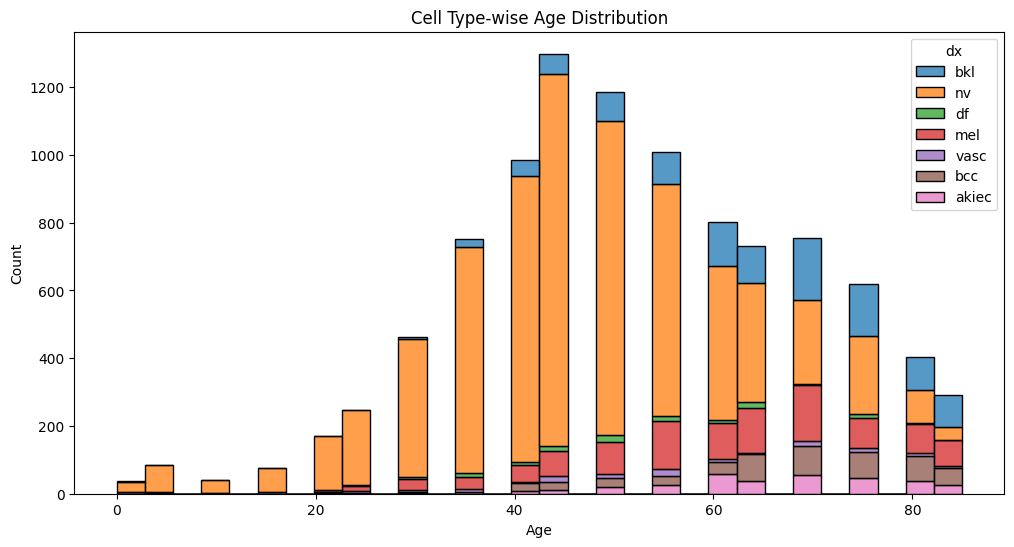

In [65]:
plt.figure(figsize=(12,6))

sns.histplot(
    data=df,
    x="age",
    hue="dx",
    bins=30,
    multiple="stack"
)

plt.title("Cell Type-wise Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")

plt.show()

/tmp/ipykernel_701/718368662.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


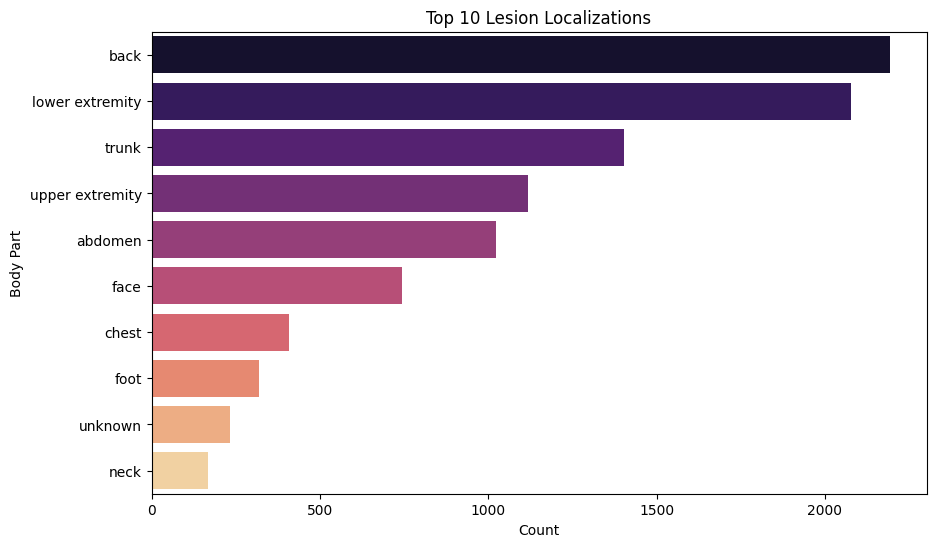

In [66]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
top_locations = df['localization'].value_counts().nlargest(10).index
sns.countplot(
    data=df[df['localization'].isin(top_locations)],
    y='localization',
    order=top_locations,
    palette='magma',
    ax=ax)
ax.set_title('Top 10 Lesion Localizations')
ax.set_xlabel('Count')
ax.set_ylabel('Body Part')


plt.show()

/tmp/ipykernel_701/1456870675.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='age', y='dx', palette='Set2')


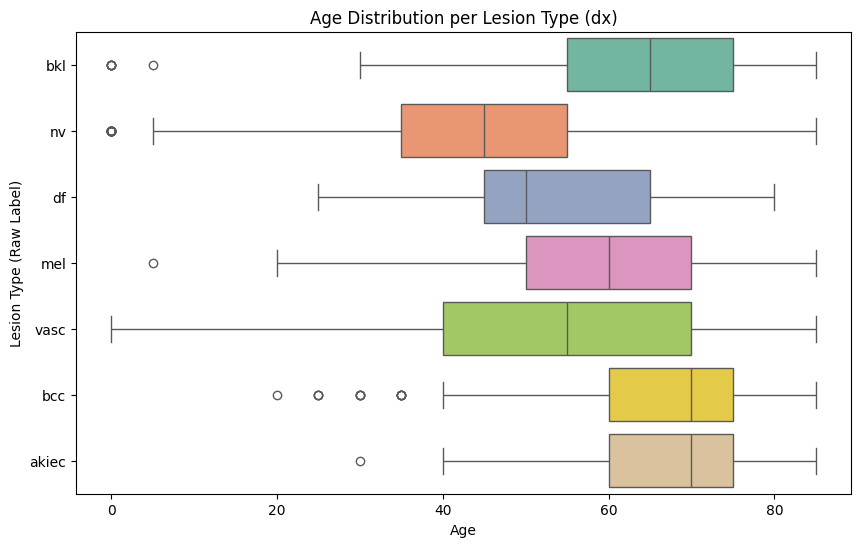

In [67]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='age', y='dx', palette='Set2')
plt.title('Age Distribution per Lesion Type (dx)')
plt.xlabel('Age')
plt.ylabel('Lesion Type (Raw Label)')
plt.show()

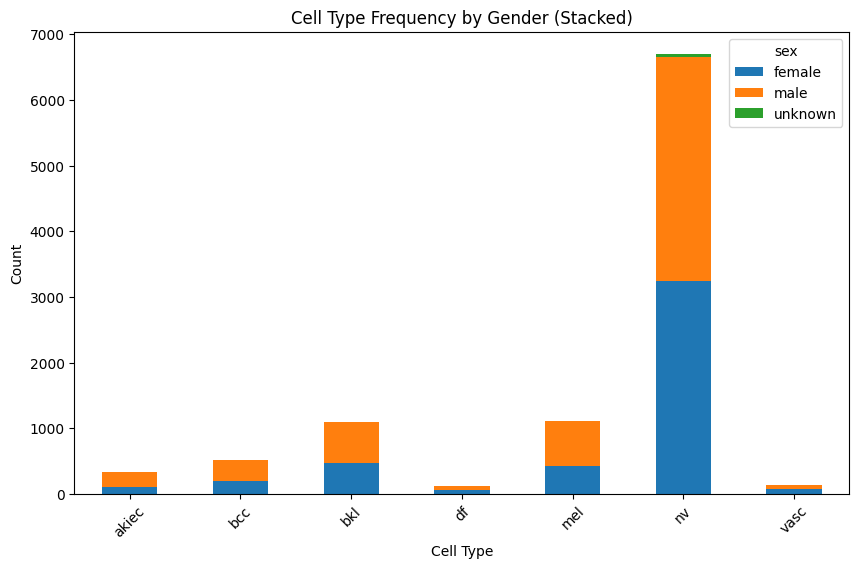

In [68]:
import pandas as pd

table = pd.crosstab(df['dx'], df['sex'])

table.plot(kind='bar', stacked=True, figsize=(10,6))

plt.title("Cell Type Frequency by Gender (Stacked)")
plt.xlabel("Cell Type")
plt.ylabel("Count")

plt.xticks(rotation=45)
plt.show()

# **Model Implementation**

In [77]:
input_shape = (64, 64, 3)
num_classes = train_generator.num_classes

model = models.Sequential()

model.add(layers.Conv2D(32, (3,3), padding='same', input_shape=input_shape))
model.add(layers.Conv2D(32, (3,3), padding='same'))
model.add(layers.Activation('relu'))
model.add(layers.BatchNormalization())

model.add(layers.Conv2D(64, (3,3), padding='same'))
model.add(layers.Conv2D(64, (3,3), padding='same'))
model.add(layers.Activation('relu'))
model.add(layers.BatchNormalization())

model.add(layers.Conv2D(128, (3,3), padding='same'))
model.add(layers.Conv2D(128, (3,3), padding='same'))
model.add(layers.Activation('relu'))
model.add(layers.BatchNormalization())

model.add(layers.Conv2D(256, (3,3), padding='same'))
model.add(layers.Conv2D(256, (3,3), padding='same'))
model.add(layers.Activation('relu'))
model.add(layers.BatchNormalization())

model.add(layers.MaxPooling2D(pool_size=(2,2)))

model.add(layers.Flatten())

model.add(layers.Dropout(0.5))

model.add(layers.Dense(256, activation='relu'))
model.add(layers.BatchNormalization())

model.add(layers.Dense(128, activation='relu'))
model.add(layers.BatchNormalization())

model.add(layers.Dense(64, activation='relu'))
model.add(layers.BatchNormalization())

model.add(layers.Dense(num_classes, activation='softmax'))

model.compile(
    optimizer=Adamax(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_40 (Conv2D)              │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_41 (Conv2D)              │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_20 (Activation)      │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_35          │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_42 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_43 (Conv2D)              │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_21 (Activation)      │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_36          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_44 (Conv2D)              │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_45 (Conv2D)              │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_22 (Activation)      │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_37          │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_46 (Conv2D)              │ (None, 64, 64, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_47 (Conv2D)              │ (None, 64, 64, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_23 (Activation)      │ (None, 64, 64, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_38          │ (None, 64, 64, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 32, 32, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 262144)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 262144)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 256)            │    67,109,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_39          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 68,326,695 (260.65 MB)

 Trainable params: 68,324,839 (260.64 MB)

 Non-trainable params: 1,856 (7.25 KB)

In [78]:
lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)


checkpoint = ModelCheckpoint(
    "dcnn_model.h5",
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

epochs = 10

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=epochs,
    callbacks=[lr_scheduler,checkpoint]
)


Epoch 1/10
1053/1053 ━━━━━━━━━━━━━━━━━━━━ 0s 387ms/step - accuracy: 0.5799 - loss: 1.1776
Epoch 1: val_accuracy improved from None to 0.81712, saving model to dcnn_model.h5



Epoch 1: finished saving model to dcnn_model.h5
1053/1053 ━━━━━━━━━━━━━━━━━━━━ 526s 488ms/step - accuracy: 0.6993 - loss: 0.8553 - val_accuracy: 0.8171 - val_loss: 0.5157 - learning_rate: 0.0010
Epoch 2/10
1053/1053 ━━━━━━━━━━━━━━━━━━━━ 0s 379ms/step - accuracy: 0.8676 - loss: 0.3913
Epoch 2: val_accuracy did not improve from 0.81712
1053/1053 ━━━━━━━━━━━━━━━━━━━━ 488s 464ms/step - accuracy: 0.8786 - loss: 0.3601 - val_accuracy: 0.7626 - val_loss: 0.6711 - learning_rate: 0.0010
Epoch 3/10
1053/1053 ━━━━━━━━━━━━━━━━━━━━ 0s 378ms/step - accuracy: 0.9248 - loss: 0.2236
Epoch 3: val_accuracy improved from 0.81712 to 0.95523, saving model to dcnn_model.h5



Epoch 3: finished saving model to dcnn_model.h5
1053/1053 ━━━━━━━━━━━━━━━━━━━━ 499s 473ms/step - accuracy: 0.9296 - loss: 0.2108 - val_accuracy: 0.9552 - val_loss: 0.1343 - learning_rate: 0.0010
Epoch 4/10
1053/1053 ━━━━━━━━━━━━━━━━━━━━ 0s 372ms/step - accuracy: 0.9625 - loss: 0.1245
Epoch 4: val_accuracy did not improve from 0.95523
1053/1053 ━━━━━━━━━━━━━━━━━━━━ 480s 456ms/step - accuracy: 0.9590 - loss: 0.1302 - val_accuracy: 0.9529 - val_loss: 0.1420 - learning_rate: 0.0010
Epoch 5/10
1053/1053 ━━━━━━━━━━━━━━━━━━━━ 0s 377ms/step - accuracy: 0.9691 - loss: 0.0991
Epoch 5: val_accuracy did not improve from 0.95523
1053/1053 ━━━━━━━━━━━━━━━━━━━━ 484s 460ms/step - accuracy: 0.9689 - loss: 0.0977 - val_accuracy: 0.9461 - val_loss: 0.1660 - learning_rate: 0.0010
Epoch 6/10
1053/1053 ━━━━━━━━━━━━━━━━━━━━ 0s 371ms/step - accuracy: 0.9790 - loss: 0.0683
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 6: val_accuracy did not improve from 0.95523
1053/1053 


Epoch 7: finished saving model to dcnn_model.h5
1053/1053 ━━━━━━━━━━━━━━━━━━━━ 501s 476ms/step - accuracy: 0.9863 - loss: 0.0424 - val_accuracy: 0.9752 - val_loss: 0.0887 - learning_rate: 5.0000e-04
Epoch 8/10
1053/1053 ━━━━━━━━━━━━━━━━━━━━ 0s 375ms/step - accuracy: 0.9882 - loss: 0.0342
Epoch 8: val_accuracy did not improve from 0.97518
1053/1053 ━━━━━━━━━━━━━━━━━━━━ 483s 458ms/step - accuracy: 0.9879 - loss: 0.0341 - val_accuracy: 0.9752 - val_loss: 0.0932 - learning_rate: 5.0000e-04
Epoch 9/10
1053/1053 ━━━━━━━━━━━━━━━━━━━━ 0s 373ms/step - accuracy: 0.9902 - loss: 0.0298
Epoch 9: val_accuracy improved from 0.97518 to 0.97613, saving model to dcnn_model.h5



Epoch 9: finished saving model to dcnn_model.h5
1053/1053 ━━━━━━━━━━━━━━━━━━━━ 543s 516ms/step - accuracy: 0.9889 - loss: 0.0315 - val_accuracy: 0.9761 - val_loss: 0.0917 - learning_rate: 5.0000e-04
Epoch 10/10
1053/1053 ━━━━━━━━━━━━━━━━━━━━ 0s 385ms/step - accuracy: 0.9904 - loss: 0.0261
Epoch 10: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 10: val_accuracy did not improve from 0.97613
1053/1053 ━━━━━━━━━━━━━━━━━━━━ 495s 470ms/step - accuracy: 0.9892 - loss: 0.0288 - val_accuracy: 0.9676 - val_loss: 0.1221 - learning_rate: 5.0000e-04


# **Evaluation**

In [79]:
y_pred_probs = model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_generator.classes
class_names = list(test_generator.class_indices.keys())

233/233 ━━━━━━━━━━━━━━━━━━━━ 96s 398ms/step


In [80]:
accuracy = accuracy_score(y_true, y_pred)
print("Accuracy:", accuracy)

print(classification_report(y_true, y_pred, target_names=class_names))

Accuracy: 0.9620661824051655
                      precision    recall  f1-score   support

   actinic_keratosis       0.98      0.99      0.99      1062
basal_cell_carcinoma       0.98      1.00      0.99      1062
    benign_keratosis       0.96      0.91      0.94      1062
      dermatofibroma       1.00      1.00      1.00      1062
    melanocytic_nevi       0.94      0.86      0.90      1062
            melanoma       0.87      0.97      0.92      1062
     vascular_lesion       1.00      1.00      1.00      1062

            accuracy                           0.96      7434
           macro avg       0.96      0.96      0.96      7434
        weighted avg       0.96      0.96      0.96      7434



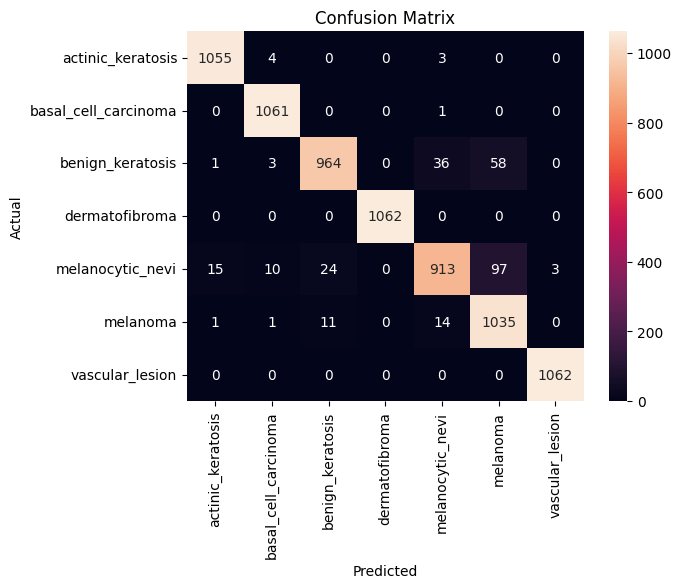

In [83]:
cm = confusion_matrix(y_true, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

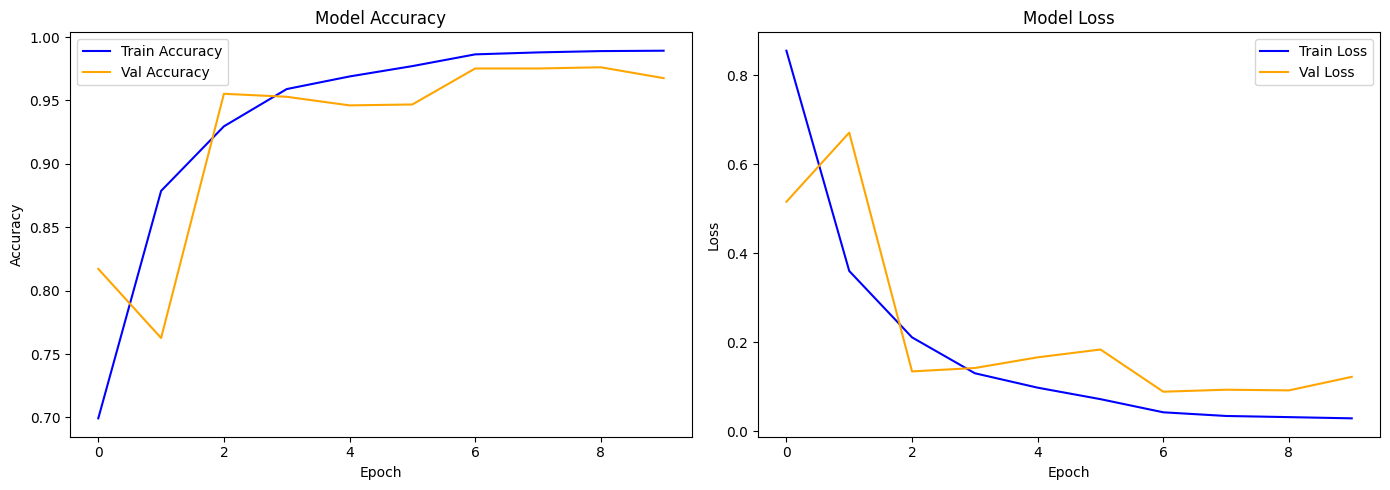

In [84]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'], label='Train Accuracy', color='blue')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy', color='orange')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'], label='Train Loss', color='blue')
axes[1].plot(history.history['val_loss'], label='Val Loss', color='orange')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()


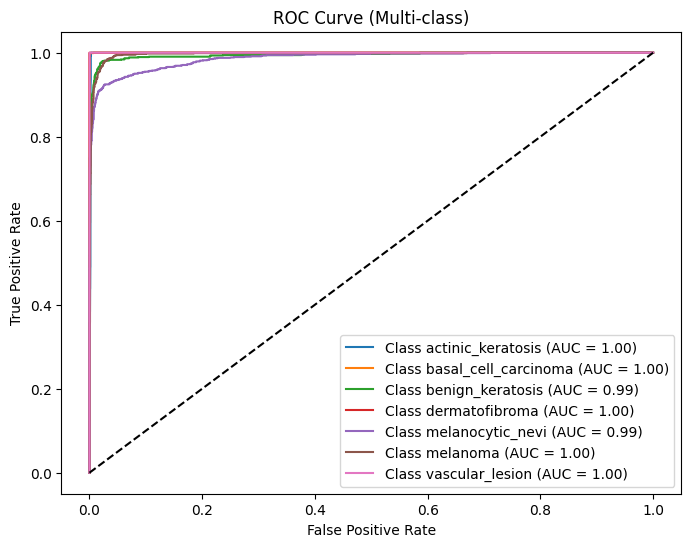

In [106]:
fpr = {}
tpr = {}
roc_auc = {}

y_true_onehot = to_categorical(y_true, num_classes=len(classes))

for i in range(len(classes)):
    fpr[i], tpr[i], _ = roc_curve(y_true_onehot[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8,6))

for i in range(len(classes)):
    plt.plot(fpr[i], tpr[i], label=f'Class {classes[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Multi-class)')
plt.legend()
plt.show()

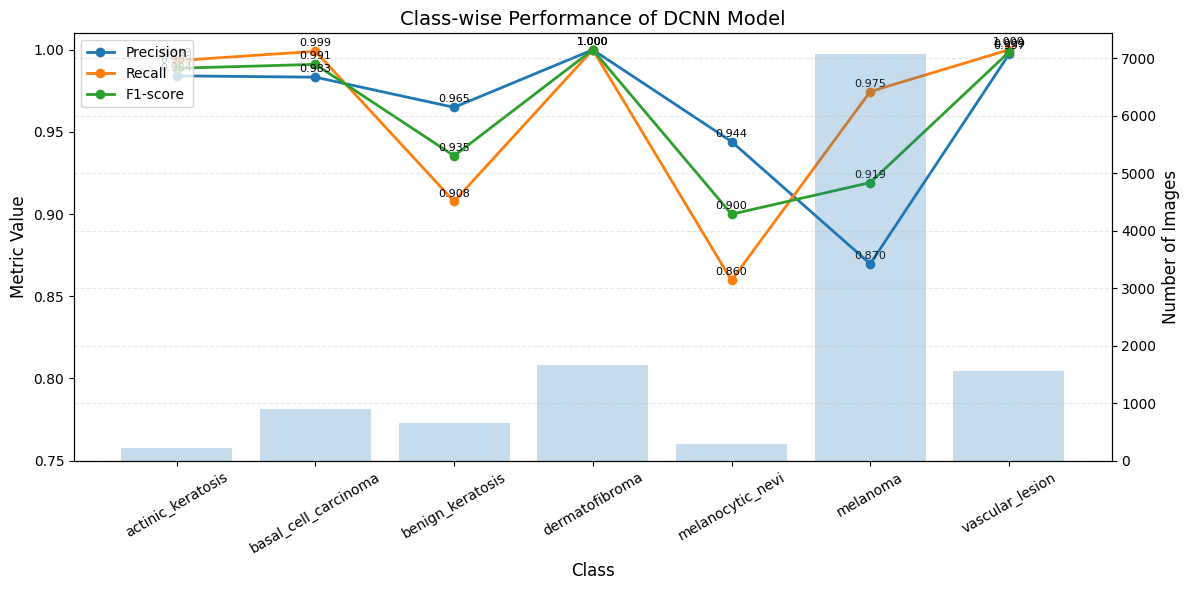

In [121]:
precision, recall, f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average=None
)

base_dir = "unified_dataset"

import matplotlib.pyplot as plt
import numpy as np

x = np.arange(len(classes))

fig, ax1 = plt.subplots(figsize=(12,6))

ax1.plot(x, precision, marker='o', linewidth=2, label='Precision')
ax1.plot(x, recall, marker='o', linewidth=2, label='Recall')
ax1.plot(x, f1, marker='o', linewidth=2, label='F1-score')

ax1.set_xlabel("Class", fontsize=12)
ax1.set_ylabel("Metric Value", fontsize=12)
ax1.set_xticks(x)
ax1.set_xticklabels(classes, rotation=30)
ax1.set_ylim(0.75, 1.01)

ax1.legend(loc='upper left')

ax2 = ax1.twinx()
bars = ax2.bar(x, counts, alpha=0.25)
ax2.set_ylabel("Number of Images", fontsize=12)

for i in range(len(classes)):
    ax1.text(x[i], precision[i]+0.003, f"{precision[i]:.3f}", ha='center', fontsize=8)
    ax1.text(x[i], recall[i]+0.003, f"{recall[i]:.3f}", ha='center', fontsize=8)
    ax1.text(x[i], f1[i]+0.003, f"{f1[i]:.3f}", ha='center', fontsize=8)

plt.title("Class-wise Performance of DCNN Model", fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()


# LIME

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


  0%|          | 0/3000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 884ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━

  0%|          | 0/3000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━

...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━

  0%|          | 0/3000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━

  0%|          | 0/3000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━

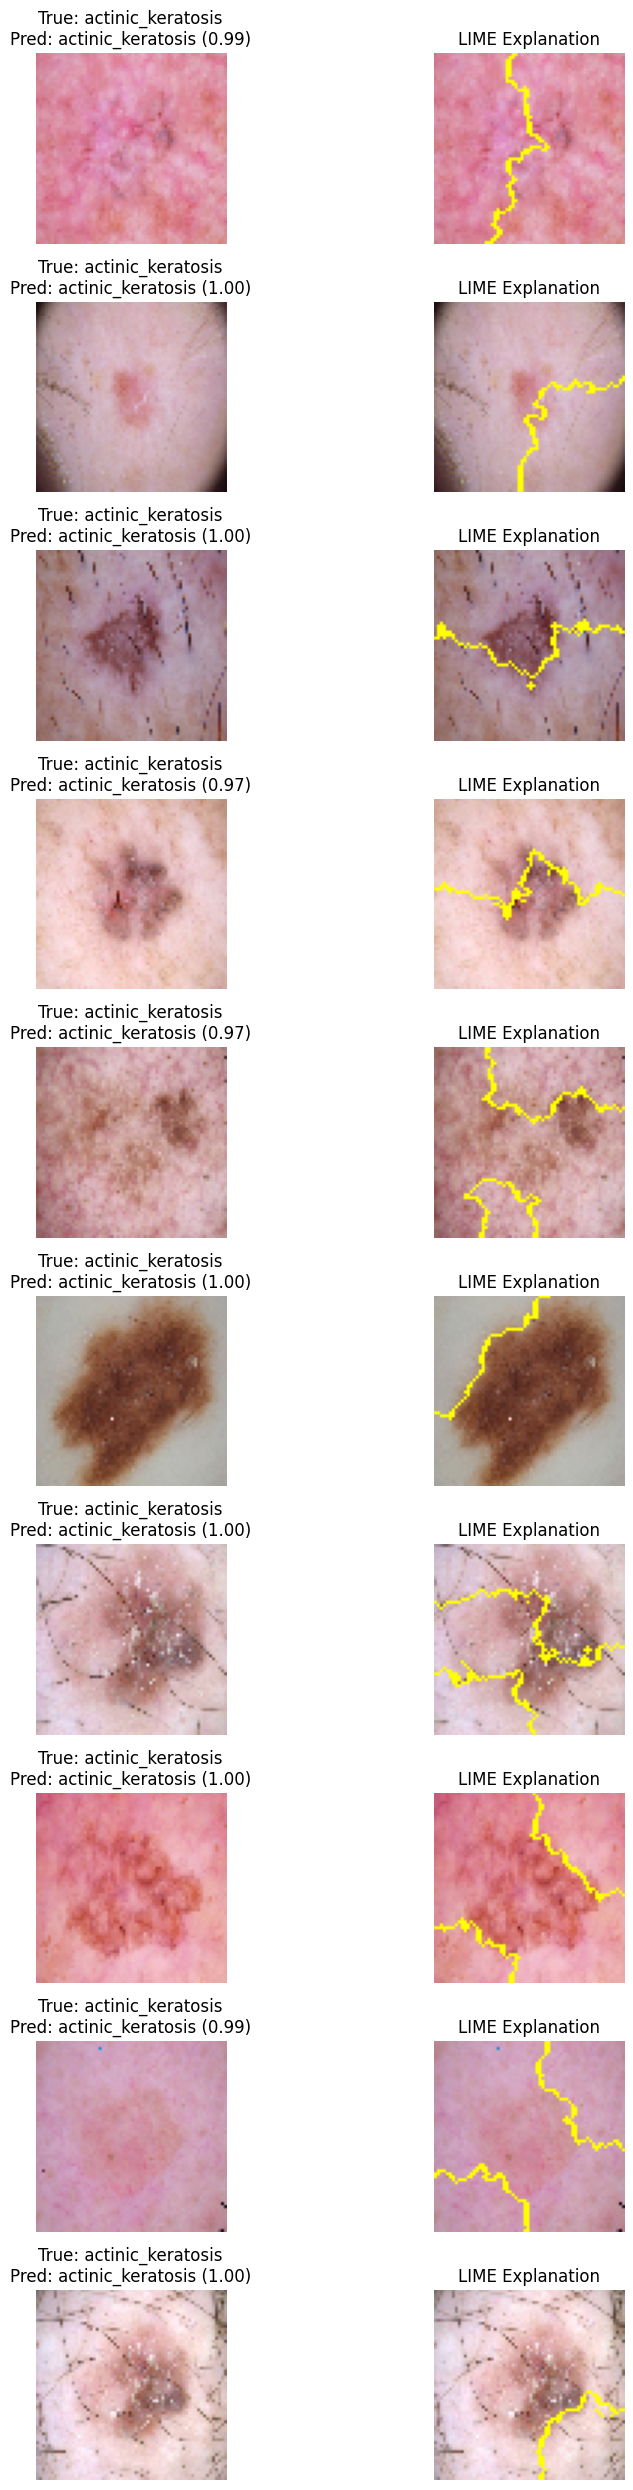

In [102]:
explainer = lime_image.LimeImageExplainer()

def predict_Img(images):
    images = images.astype('float32') / 255.0
    return model.predict(images)

class_names = list(test_generator.class_indices.keys())

plt.figure(figsize=(10, 25))

for i in range(10):

    image, label = test_generator[i]
    image = image[0]
    true_label = np.argmax(label[0])

    if image.shape[-1] == 1:
        image = np.repeat(image, 3, axis=-1)

    preds = model.predict(image[np.newaxis, ...])
    pred_class = np.argmax(preds)
    confidence = np.max(preds)

    explanation = explainer.explain_instance(
        image,
        predict_Img,
        labels=(pred_class,),
        hide_color=0,
        num_samples=3000
    )

    plt.subplot(10, 2, 2*i + 1)
    plt.imshow(image)
    plt.title(f"True: {class_names[true_label]}\nPred: {class_names[pred_class]} ({confidence:.2f})")
    plt.axis('off')

    try:
        temp, mask = explanation.get_image_and_mask(
            pred_class,
            positive_only=True,
            num_features=10,
            hide_rest=False
        )
        plt.subplot(10, 2, 2*i + 2)
        plt.imshow(mark_boundaries(temp, mask))
        plt.title("LIME Explanation")
        plt.axis('off')
    except KeyError:
        plt.subplot(10, 2, 2*i + 2)
        plt.imshow(image)
        plt.title("LIME Explanation Failed")
        plt.axis('off')

plt.tight_layout()
plt.show()